# Derivate parziali, punti critici e discesa del gradiente

Questo notebook ripercorre il calcolo differenziale per funzioni di più variabili — derivate parziali, gradiente, piano tangente, Hessiana — fino alla classificazione dei punti stazionari, per poi usare proprio questi strumenti per introdurre e confrontare due algoritmi di ottimizzazione. Il percorso è organizzato in quattro step:

1. **Step 1 — Derivate parziali e superficie di una funzione di due variabili.** Calcolo simbolico delle derivate parziali e loro conversione in funzioni numeriche, visualizzazione della superficie.
2. **Step 2 — Gradiente, piano tangente e curve di livello.** Il gradiente come direzione di massima crescita e come base dell'approssimazione lineare locale.
3. **Step 3 — Punti critici, Hessiana e classificazione.** Un esempio con tutti e tre i tipi di punto stazionario: minimo, massimo e sella.
4. **Step 4 — Extra: discesa del gradiente a confronto con Newton.** Lo stesso problema di minimizzazione già visto in un notebook precedente, risolto questa volta con l'algoritmo di discesa del gradiente, per contrastarne velocità e sensibilità al passo con quelle del metodo di Newton smorzato.

## Perché le derivate parziali

Per una funzione di più variabili non ha senso parlare di "la" derivata: la variazione di $f$ dipende dalla direzione lungo cui ci si muove. Le derivate parziali isolano le direzioni più semplici (quelle degli assi coordinati), e il gradiente le combina in un unico oggetto — un vettore — che indica la direzione di massima crescita di $f$ e allo stesso tempo permette di costruire l'approssimazione lineare locale della funzione (il piano tangente). Spingendosi al second'ordine, la matrice Hessiana gioca lo stesso ruolo che la derivata seconda gioca nel caso di una sola variabile: distingue un minimo da un massimo o da una sella, cioè risponde alla domanda "il punto stazionario che ho trovato è davvero un ottimo, o no?".

Questo apparato — gradiente e Hessiana — è anche il punto di partenza di ogni algoritmo di ottimizzazione numerica. Il più semplice, la **discesa del gradiente**, fu proposto da Augustin-Louis Cauchy nel 1847 come metodo generale per risolvere sistemi di equazioni simultanee, e resta oggi l'algoritmo di base dietro l'allenamento della quasi totalità dei modelli di machine learning: usa solo il gradiente, muovendosi ripetutamente nella direzione di discesa più ripida. Il metodo di Newton (già visto in un notebook precedente per lo stesso tipo di problema) usa in più la Hessiana, pagando un costo maggiore per iterazione in cambio di una convergenza molto più rapida. Il confronto diretto tra i due, nell'ultimo step di questo notebook, è pensato proprio per rendere tangibile questo compromesso.

### Import e librerie

Importiamo `numpy` per il calcolo numerico, `matplotlib.pyplot` per i grafici e `sympy` per il calcolo simbolico. Le funzioni riutilizzabili di questo notebook non sono definite qui: `to_numeric` e `newton_damped_vett` vivono nei moduli condivisi `src/symbolic_utils.py` e `src/newton.py`, già creati nei notebook precedenti; `classify_critical_points` (Step 3) e `gradient_descent` (Step 4) vivono nei nuovi moduli `src/calculus.py` e `src/gradient_descent.py`, creati appositamente per questo notebook.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from src.symbolic_utils import to_numeric
from src.newton import newton_damped_vett
from src.calculus import classify_critical_points
from src.gradient_descent import gradient_descent

## Step 1 — Derivate parziali e superficie di una funzione di due variabili

### Definizione

Data $f:\mathbb{R}^2\to\mathbb{R}$, la derivata parziale rispetto a $x$ nel punto $(x,y)$ è il limite

$$\frac{\partial f}{\partial x}(x,y) = \lim_{h\to0}\frac{f(x+h,y)-f(x,y)}{h},$$

cioè la derivata ordinaria di $f$ vista come funzione della sola $x$, con $y$ tenuta fissa (analogamente per $\partial f/\partial y$, fissando $x$). Geometricamente, $\partial f/\partial x(x_0,y_0)$ è la pendenza della curva ottenuta intersecando la superficie $z=f(x,y)$ con il piano verticale $y=y_0$.

### La funzione di prova

Si usa

$$f(x,y) = x\sin(y) - y\cos(x),$$

una combinazione di termini trigonometrici che mescola $x$ e $y$ in entrambi gli addendi (diversa dalla funzione $x^2y+\sin(xy)$ vista a lezione, anche se la costruzione — un prodotto misto più un termine trigonometrico — è concettualmente simile). Le derivate parziali si calcolano derivando un addendo alla volta:

$$\frac{\partial f}{\partial x} = \sin(y) + y\sin(x), \qquad \frac{\partial f}{\partial y} = x\cos(y) - \cos(x).$$

In [2]:
x, y = sp.symbols('x y')
f1_sym = x*sp.sin(y) - y*sp.cos(x)

df1_dx = sp.diff(f1_sym, x)
df1_dy = sp.diff(f1_sym, y)

print('f(x,y)              =', f1_sym)
print('df/dx                =', df1_dx)
print('df/dy                =', df1_dy)

f1_num = to_numeric(f1_sym, (x, y))
df1_dx_num = to_numeric(df1_dx, (x, y))
df1_dy_num = to_numeric(df1_dy, (x, y))

f(x,y)              = x*sin(y) - y*cos(x)
df/dx                = y*sin(x) + sin(y)
df/dy                = x*cos(y) - cos(x)


### Visualizzazione della superficie

Un grafico 3D di $z=f(x,y)$ dà un'idea visiva della funzione prima di procedere, nei prossimi step, all'analisi del suo comportamento tramite gradiente e Hessiana.

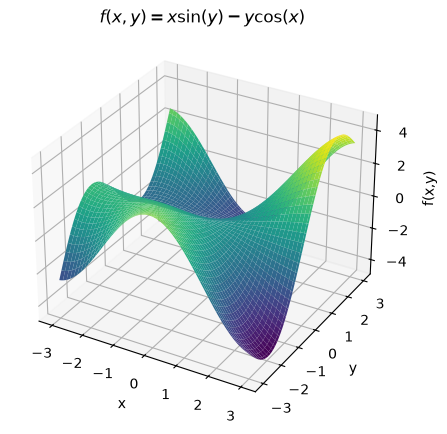

In [3]:
xx = np.linspace(-3, 3, 100)
yy = np.linspace(-3, 3, 100)
XX, YY = np.meshgrid(xx, yy)
ZZ = f1_num(XX, YY)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX, YY, ZZ, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title(r'$f(x,y) = x\sin(y) - y\cos(x)$')
plt.show()

## Step 2 — Gradiente, piano tangente e curve di livello

### Il gradiente e le sue due proprietà

Il gradiente di $f$ è il vettore delle derivate parziali, $\nabla f(x,y) = \big(\partial f/\partial x,\ \partial f/\partial y\big)$. Ha due proprietà centrali:

1. **Direzione di massima crescita.** Tra tutte le direzioni unitarie $\mathbf{u}$, la derivata direzionale $\nabla f(x,y)\cdot\mathbf{u}$ è massima quando $\mathbf{u}$ è parallelo a $\nabla f(x,y)$ — il gradiente punta cioè nella direzione in cui $f$ cresce più rapidamente, e la sua norma $\|\nabla f\|$ ne misura la rapidità.
2. **Ortogonalità alle curve di livello.** Lungo una curva di livello $f(x,y)=c$, per definizione $f$ non cambia; si può mostrare che questo implica $\nabla f$ perpendicolare alla curva in ogni suo punto. Le due proprietà sono in realtà la stessa cosa vista da due angolazioni: muoversi lungo la curva di livello (dove $f$ non cresce) è la direzione con derivata direzionale nulla, quindi ortogonale a quella di massima crescita.

### Piano tangente

Il gradiente fornisce anche l'approssimazione lineare locale di $f$ attorno a un punto $(x_0,y_0)$ — il piano tangente alla superficie $z=f(x,y)$:

$$z = f(x_0,y_0) + \nabla f(x_0,y_0)\cdot(x-x_0,\ y-y_0).$$

### La funzione di prova

Si usa il paraboloide ellittico

$$f(x,y) = 2x^2+y^2,$$

diverso dal paraboloide circolare $x^2+y^2$ visto a lezione (i due assi hanno curvatura diversa, quindi le curve di livello sono ellissi, non cerchi). Il gradiente è $\nabla f(x,y) = (4x,\,2y)$.

In [4]:
f2_sym = 2*x**2 + y**2
grad2_sym = sp.Matrix([sp.diff(f2_sym, x), sp.diff(f2_sym, y)])
print('f(x,y)   =', f2_sym)
print('grad f   =', grad2_sym.T)

f2_num = to_numeric(f2_sym, (x, y))
grad2_num = to_numeric(grad2_sym, (x, y))

f(x,y)   = 2*x**2 + y**2
grad f   = Matrix([[4*x, 2*y]])


### Piano tangente in un punto non banale

Si calcola il piano tangente in $(x_0,y_0)=(1,-1)$ (un punto qualsiasi, non l'origine, per evitare il caso degenere in cui il gradiente si annulla).

In [5]:
x0, y0 = 1, -1
z0 = f2_sym.subs({x: x0, y: y0})
grad0 = grad2_sym.subs({x: x0, y: y0})

piano = z0 + grad0[0]*(x - x0) + grad0[1]*(y - y0)
piano = sp.expand(piano)

print('f(x0,y0)      =', z0)
print('grad f(x0,y0) =', grad0.T)
print('piano tangente:', piano)

f(x0,y0)      = 3
grad f(x0,y0) = Matrix([[4, -2]])
piano tangente: 4*x - 2*y - 3


### Curve di livello e campo del gradiente

Si sovrappone alle curve di livello di $f$ il campo vettoriale del gradiente (`quiver`): per la proprietà di ortogonalità discussa sopra, ci si aspetta che ogni freccia sia perpendicolare alla curva di livello che attraversa, e punti verso l'esterno (verso valori di $f$ crescenti).

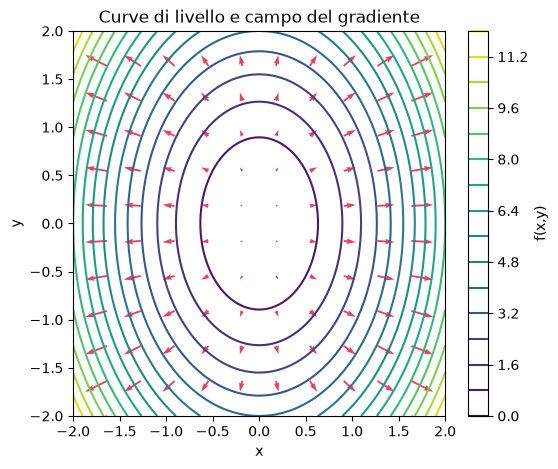

In [6]:
xg = np.linspace(-2, 2, 400)
yg = np.linspace(-2, 2, 400)
XG, YG = np.meshgrid(xg, yg)
ZG = f2_num(XG, YG)

xq = np.linspace(-2, 2, 12)
yq = np.linspace(-2, 2, 12)
XQ, YQ = np.meshgrid(xq, yq)
grad_vals = grad2_num(XQ, YQ)
U, V = grad_vals[0, 0], grad_vals[1, 0]

plt.figure(figsize=(6, 5))
cs = plt.contour(XG, YG, ZG, levels=15)
plt.colorbar(cs, label='f(x,y)')
plt.quiver(XQ, YQ, U, V, units='x', color='crimson', alpha=0.8)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curve di livello e campo del gradiente')
plt.show()

## Step 3 — Punti critici, Hessiana e classificazione

### Condizione necessaria e condizione sufficiente

Un punto $(x^*,y^*)$ è **stazionario** (o critico) se $\nabla f(x^*,y^*)=(0,0)$: è la condizione **necessaria** del prim'ordine per un estremo locale, soddisfatta indifferentemente da minimi, massimi e selle. Per distinguerli serve il second'ordine: la matrice **Hessiana**

$$Hf(x,y) = \begin{pmatrix}\partial^2f/\partial x^2 & \partial^2f/\partial x\partial y \\ \partial^2f/\partial x\partial y & \partial^2f/\partial y^2\end{pmatrix}$$

valutata nel punto stazionario. Guardando i suoi autovalori $\lambda_1,\lambda_2$ (Hessiana simmetrica, quindi autovalori reali):

- entrambi positivi $\Rightarrow$ **minimo locale**;
- entrambi negativi $\Rightarrow$ **massimo locale**;
- di segno opposto $\Rightarrow$ **punto di sella**.

(Il caso di un autovalore nullo è degenere e richiederebbe un'analisi di ordine superiore — non si presenta nell'esempio seguente.)

### Una funzione con tutti e tre i casi

Si usa

$$f(x,y) = x^4 - 2x^2 + y^3 - 3y,$$

diversa da $x^3-3x+y^2$ vista a lezione, e scelta apposta per produrre **tutti e tre** i tipi di punto critico in un solo esempio (a lezione se ne vedono solo due, minimo e sella). A mano: $\partial f/\partial x = 4x^3-4x = 4x(x^2-1)=0 \Rightarrow x\in\{0,\pm1\}$, $\partial f/\partial y = 3y^2-3=0 \Rightarrow y=\pm1$, quindi 6 punti critici $(0,\pm1)$, $(\pm1,\pm1)$. La Hessiana è diagonale, $Hf=\begin{pmatrix}12x^2-4 & 0\\0 & 6y\end{pmatrix}$ (quindi i suoi autovalori sono semplicemente gli elementi diagonali): per $x=0$ si ha $12x^2-4=-4<0$, per $x=\pm1$ si ha $12x^2-4=8>0$; per $y=1$ si ha $6y=6>0$, per $y=-1$ si ha $6y=-6<0$. Combinando: $(0,1)$ e $(0,-1)$ hanno il primo autovalore negativo, quindi non possono essere minimi; $(0,-1)$ ha entrambi negativi (massimo), $(0,1)$ ha segni opposti (sella); $(\pm1,1)$ hanno entrambi positivi (minimo), $(\pm1,-1)$ hanno segni opposti (sella) — in tutto **2 minimi, 1 massimo, 3 selle**, da verificare sotto con sympy invece di fidarsi solo del calcolo a mano.

In [7]:
f3_sym = x**4 - 2*x**2 + y**3 - 3*y

critici = classify_critical_points(f3_sym, (x, y))

print(f"{'punto':<12}{'autovalori':<28}{'tipo':<10}")
for c in critici:
    print(f"{str(c['point']):<12}{str(c['eigenvalues']):<28}{c['type']:<10}")

punto       autovalori                  tipo      
(-1, -1)    [-6.00000000000000, 8.00000000000000]sella     
(-1, 1)     [6.00000000000000, 8.00000000000000]minimo    
(0, -1)     [-6.00000000000000, -4.00000000000000]massimo   
(0, 1)      [-4.00000000000000, 6.00000000000000]sella     
(1, -1)     [-6.00000000000000, 8.00000000000000]sella     
(1, 1)      [6.00000000000000, 8.00000000000000]minimo    


### Visualizzazione: i tre tipi di punto critico sulla superficie

Si disegna la superficie di $f$ con i sei punti critici marcati, colorati per tipo (verde = minimo, rosso = massimo, arancione = sella), a conferma visiva della classificazione ottenuta sopra.

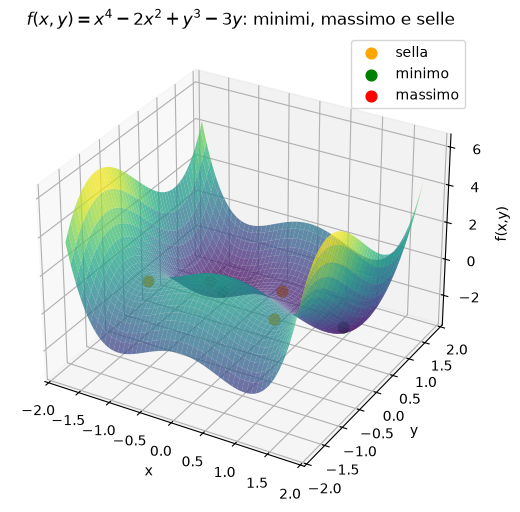

In [8]:
f3_num = to_numeric(f3_sym, (x, y))

xs = np.linspace(-1.8, 1.8, 150)
ys = np.linspace(-1.8, 1.8, 150)
XS, YS = np.meshgrid(xs, ys)
ZS = f3_num(XS, YS)

color_by_type = {'minimo': 'green', 'massimo': 'red', 'sella': 'orange'}

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XS, YS, ZS, cmap='viridis', alpha=0.75)

for c in critici:
    px, py = float(c['point'][0]), float(c['point'][1])
    pz = f3_num(px, py)
    ax.scatter(px, py, pz, color=color_by_type[c['type']], s=60, label=c['type'])

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title(r'$f(x,y)=x^4-2x^2+y^3-3y$: minimi, massimo e selle')
plt.show()

## Step 4 — Extra: discesa del gradiente a confronto con Newton

### L'algoritmo

La discesa del gradiente cerca un minimo muovendosi ripetutamente nella direzione opposta al gradiente (quella di massima *discesa*, per la prima proprietà discussa allo Step 2):

$$x_{k+1} = x_k - \eta\,\nabla f(x_k),$$

dove $\eta>0$ è il **learning rate** (o passo). A differenza di Newton, non serve calcolare né invertire alcuna matrice: ogni iterazione costa una sola valutazione del gradiente, molto più economica di risolvere un sistema lineare $n\times n$ con la Hessiana. Il prezzo si vede nella velocità di convergenza: mentre Newton converge quadraticamente vicino a un minimo regolare, la discesa del gradiente converge solo **linearmente**, con un tasso che peggiora quanto più la Hessiana nel minimo è mal condizionata (direzioni con curvatura molto diversa fanno "zigzagare" l'algoritmo).

### Stesso problema di `newton_min.ipynb`, per un confronto ad armi pari

Per confrontare i due metodi sullo stesso terreno si riusa la quartica non convessa già vista in un notebook precedente per Newton smorzato,

$$f(x,y) = x^4+y^4-4xy+1,$$

con lo stesso punto di partenza $x_0=(1.5,1.5)$ e lo stesso minimo bersaglio $(1,1)$, dove — come già verificato in quel notebook — la Hessiana $Hf(1,1)=\begin{pmatrix}12&-4\\-4&12\end{pmatrix}$ ha autovalori $\{8,16\}$, entrambi positivi.

In [9]:
f4_sym = x**4 + y**4 - 4*x*y + 1
grad4_sym = sp.Matrix([sp.diff(f4_sym, x), sp.diff(f4_sym, y)])
hess4_sym = sp.hessian(f4_sym, (x, y))

grad4_num = to_numeric(grad4_sym, [(x, y)])
hess4_num = to_numeric(hess4_sym, [(x, y)])

### Tre learning rate a confronto, e il confronto con Newton

Da $x_0=(1.5,1.5)$ si lancia `gradient_descent` con tre learning rate: uno piccolo ma funzionante ($\eta=0.02$), uno "buono" ($\eta=0.1$), e uno troppo grande ($\eta=0.3$) scelto apposta per mostrare l'instabilità. Per confronto, si rilancia anche `newton_damped_vett` (già usato in `newton_min.ipynb`) sullo stesso problema.

In [10]:
x0_gd = np.array([1.5, 1.5])
nmax_gd = 500
learning_rates = [0.02, 0.1, 0.3]

print(f"{'lr':<8}{'xs':<24}{'n_it':<8}{'convergente'}")
gd_results = {}
for lr in learning_rates:
    xs_lr, g_lr, n_it_lr, path_lr = gradient_descent(grad4_num, x0_gd, lr, atol=1e-8, rtol=1e-8, nmax=nmax_gd)
    gd_results[lr] = (xs_lr, n_it_lr, path_lr)
    convergente = 'si' if n_it_lr < nmax_gd else 'no'
    xs_str = f"({xs_lr[0]:.4f}, {xs_lr[1]:.4f})"
    print(f"{lr:<8}{xs_str:<24}{n_it_lr:<8}{convergente}")

xs_newton, g_newton, H_newton, n_it_newton, _ = newton_damped_vett(grad4_num, hess4_num, x0_gd, alpha=0.9, atol=1e-8, rtol=1e-8, nmax=100)
print(f"\nNewton smorzato (alpha=0.9): xs=({xs_newton[0]:.4f}, {xs_newton[1]:.4f}), n_it={n_it_newton}")

lr      xs                      n_it    convergente
0.02    (1.0000, 1.0000)        86      si
0.1     (1.0000, 1.0000)        14      si
0.3     (-1.1395, -1.1395)      500     no

Newton smorzato (alpha=0.9): xs=(1.0000, 1.0000), n_it=10


### Il percorso di discesa

Si visualizza, sulle curve di livello di $f$, il percorso seguito dalla discesa del gradiente con il learning rate "buono" ($\eta=0.1$).

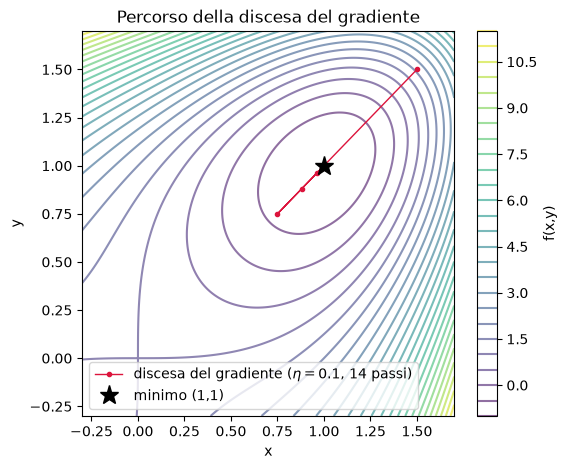

In [11]:
path_good = gd_results[0.1][2]

xp = np.linspace(-0.3, 1.7, 300)
yp = np.linspace(-0.3, 1.7, 300)
XP, YP = np.meshgrid(xp, yp)
ZP = XP**4 + YP**4 - 4*XP*YP + 1

plt.figure(figsize=(6, 5))
cs = plt.contour(XP, YP, ZP, levels=25, alpha=0.6)
plt.colorbar(cs, label='f(x,y)')
plt.plot(path_good[:, 0], path_good[:, 1], 'o-', color='crimson', markersize=3, linewidth=1, label=f'discesa del gradiente ($\\eta=0.1$, {len(path_good)-1} passi)')
plt.plot(1, 1, '*', color='black', markersize=14, label='minimo (1,1)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Percorso della discesa del gradiente')
plt.show()

### Interpretazione: lineare contro quadratica, e il prezzo di un passo troppo grande

I numeri confermano quanto previsto dalla teoria. Con $\eta=0.02$ la discesa del gradiente converge in **86 iterazioni**; con $\eta=0.1$ ne bastano **14** — un passo più lungo sfrutta meglio il gradiente, ma solo fino a un certo punto: con $\eta=0.3$ l'algoritmo **non converge** entro le 500 iterazioni concesse, e resta a oscillare vicino a $(-1.14,-1.14)$ senza mai stabilizzarsi (il grafico del percorso qui sopra usa $\eta=0.1$, quello stabile). Il metodo di Newton smorzato, sullo stesso problema e con lo stesso punto di partenza, converge in **10 iterazioni** — nell'ordine di grandezza del miglior caso della discesa del gradiente, non di uno o due passi in più: è la differenza pratica tra convergenza lineare e quadratica.

Il ruolo del learning rate $\eta$ e quello del passo di smorzamento $\alpha$ di Newton sono concettualmente diversi, anche se a prima vista sembrano lo stesso tipo di parametro. $\alpha$ (visto in `newton_min.ipynb`) scala un passo che punta già, per costruzione, in una buona direzione (quella data dalla Hessiana): può solo rallentare la convergenza, non deviarla, e valori diversi non hanno mai causato instabilità in quel notebook. Il learning rate $\eta$, qui, scala invece un passo che usa **solo** l'informazione locale del gradiente, senza alcuna nozione di curvatura: se $\eta$ è troppo grande rispetto alla curvatura di $f$ nella zona attraversata, il passo può "scavalcare" la valle e allontanarsi invece di avvicinarsi, come mostrato sopra con $\eta=0.3$. Questa è la ragione di fondo per cui scegliere un buon learning rate è, nella pratica, uno dei problemi centrali dei metodi basati sul solo gradiente (compreso l'allenamento delle reti neurali).

## Conclusioni e limiti

I quattro step di questo notebook costruiscono, uno sopra l'altro, l'apparato del calcolo differenziale multivariato e lo applicano all'ottimizzazione:

- **Derivate parziali e gradiente** (Step 1-2): il gradiente è al tempo stesso la direzione di massima crescita di $f$ e la base dell'approssimazione lineare locale (piano tangente) — due facce della stessa idea, verificate rispettivamente sul campo vettoriale sovrapposto alle curve di livello e sul calcolo esplicito del piano tangente.
- **Hessiana e classificazione dei punti critici** (Step 3): $\nabla f=0$ è solo condizione necessaria; servono gli autovalori della Hessiana per distinguere minimo, massimo e sella — con un solo esempio che li mostra tutti e tre.
- **Discesa del gradiente contro Newton smorzato** (Step 4): stesso problema, stesso punto di partenza, due algoritmi che usano informazioni diverse (solo gradiente contro gradiente e Hessiana) e mostrano velocità di convergenza molto diverse — lineare contro quadratica — insieme a un rischio specifico della discesa del gradiente che Newton smorzato, nell'esempio usato, non presenta: un passo troppo lungo può far divergere l'iterazione invece di rallentarla soltanto.

Un limite comune a entrambi gli algoritmi discussi allo Step 4: nessuno dei due garantisce di trovare un **minimo globale** — solo un punto stazionario (Newton) o un minimo locale raggiungibile dal punto di partenza scelto (discesa del gradiente, quando converge). Su una funzione con più minimi locali, punti di partenza diversi possono condurre a risultati diversi, esattamente come già visto per Newton-per-sistemi in un notebook precedente. La scelta dell'algoritmo, in pratica, è sempre un compromesso tra il costo per iterazione (basso per la discesa del gradiente, più alto per Newton, che richiede la Hessiana) e il numero di iterazioni necessario — nessuno dei due è "il migliore" in assoluto.